# Disease module analysis

Some things to work on
- It seems that the quality of nucleic acid predictions by Pesto is quite poor, looking at many of the proteins it identifies as nucleic acid binders based on UniProt functional annotation they are clearly not nucleic acid binders.
- Improving which proteins we identify in the disease associations.

In [1]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Network construction
Construct 5 networks, one for each modality (protein, lipid, nucleic acid, ligand, and ion) using protein interface similarity defined by InteractNN embeddiings.

In [2]:
embeddings_data_dir = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/embeddings_fixed_irreps/"

In [7]:
modality = "ion"
pesto_cutoff = 70
plddt_cutoff = 70

graph_stats = []
cutoffs = [0.97, 0.98, 0.985, 0.986, 0.987, 0.989, 0.99, 0.991, 0.992, 0.993, 0.993, 0.995, 0.999]
for cutoff in tqdm(cutoffs, total=len(cutoffs)):
    with open(os.path.join(embeddings_data_dir, f"pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl"), "rb") as f:
        embeddings_dataset = pickle.load(f)

    embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
    uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}

    similarity_matrix = cosine_similarity(embeddings)

    indices = np.triu_indices_from(similarity_matrix, k=1)
    filtered_indices = indices[0][similarity_matrix[indices] > cutoff], indices[1][similarity_matrix[indices] > cutoff]

    G = nx.Graph()
    G.add_nodes_from(range(len(embeddings)))
    edges = zip(filtered_indices[0], filtered_indices[1], similarity_matrix[filtered_indices])
    G.add_weighted_edges_from(edges)
    num_connected_components = nx.number_connected_components(G)
    size_of_largest_connected_component = max([len(x) for x in nx.connected_components(G)])
    whole_graph_density = nx.density(G)
    whole_graph_clustering = nx.average_clustering(G)

    graph_stats.append({
        "modality": modality,
        "cutoff": cutoff,
        "num_embeddings": len(embeddings),
        "num_edges": filtered_indices[0].shape[0],
        "size_of_largest_connected_component": size_of_largest_connected_component,
        "proportion_of_largest_connected_component": size_of_largest_connected_component / len(embeddings),
        "num_connected_components": num_connected_components,
        "density": whole_graph_density,
        "clustering": whole_graph_clustering,
        "average_degree": np.mean([x[1] for x in G.degree()])
    })

graph_stats_df = pd.DataFrame(graph_stats)

100%|██████████| 13/13 [01:20<00:00,  6.19s/it]


In [8]:
graph_stats_df

,modality,cutoff,num_embeddings,num_edges,size_of_largest_connected_component,proportion_of_largest_connected_component,num_connected_components,density,clustering,average_degree
0,ion,0.970,6458,442019,6393,0.989935,51,0.021200,0.560202,136.890369
1,ion,0.980,6458,251838,6298,0.975225,121,0.012079,0.522715,77.992567
2,ion,0.985,6458,164310,6157,0.953391,234,0.007881,0.490475,50.885723
3,ion,0.986,6458,147551,6116,0.947042,268,0.007077,0.480869,45.695571
4,ion,0.987,6458,131191,6059,0.938216,316,0.006292,0.470024,40.628987
5,ion,0.989,6458,100422,5870,0.908950,455,0.004816,0.450132,31.100031
6,ion,0.990,6458,85552,5716,0.885104,549,0.004103,0.436527,26.494890
7,ion,0.991,6458,71677,5501,0.851812,665,0.003438,0.419794,22.197894
8,ion,0.992,6458,58476,5254,0.813565,813,0.002805,0.399646,18.109631
9,ion,0.993,6458,46113,4121,0.638123,1023,0.002212,0.371481,14.280892


Text(0, 0.5, 'Average Degree')

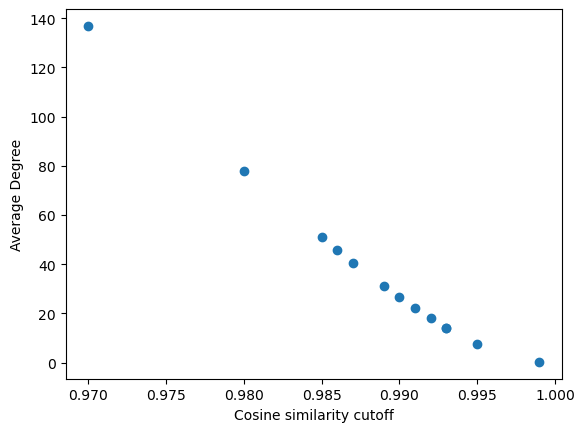

In [12]:
plt.scatter(graph_stats_df['cutoff'], graph_stats_df['average_degree'])
plt.xlabel('Cosine similarity cutoff')
plt.ylabel('Average Degree')

In [4]:
# cosine similarity cut offs for 90% of the nodes to belong to the giant connected component
pesto_cutoff = 70
plddt_cutoff = 70

modality_cutoff = {
    "protein": 0.9966,
    "lipid": 0.9945,
    "nucleic_acid": 0.994,
    "ligand": 0.992,
    "ion": 0.989,
}

modality_graphs = {}

for modality, cutoff in modality_cutoff.items():
    with open(os.path.join(embeddings_data_dir, f"pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl"), "rb") as f:
        embeddings_dataset = pickle.load(f)

    embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
    uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}

    similarity_matrix = cosine_similarity(embeddings)

    indices = np.triu_indices_from(similarity_matrix, k=1)
    filtered_indices = indices[0][similarity_matrix[indices] > cutoff], indices[1][similarity_matrix[indices] > cutoff]

    print(f"-----------------{modality}-----------------")
    print("Number of embeddings: ", embeddings.shape)
    print("num edges: ", filtered_indices[0].shape[0])

    G = nx.Graph()
    G.add_nodes_from(range(len(embeddings)))
    edges = zip(filtered_indices[0], filtered_indices[1], similarity_matrix[filtered_indices])
    G.add_weighted_edges_from(edges)
    num_connected_components = nx.number_connected_components(G)
    size_of_largest_connected_component = max([len(x) for x in nx.connected_components(G)])
    whole_graph_density = nx.density(G)
    whole_graph_clustering = nx.average_clustering(G)
    print("size of largest connected component: ", size_of_largest_connected_component)
    print("proportion of largest connected component: ", size_of_largest_connected_component / len(embeddings))
    print("number of connected components", num_connected_components)
    print("density: ", whole_graph_density)
    print("clustering: ", whole_graph_clustering)
    print("average degree: ", np.mean([x[1] for x in G.degree()]))

    largest_component = max(nx.connected_components(G), key=len)
    largest_component_subgraph = G.subgraph(largest_component).copy()
    G = largest_component_subgraph

    adjacency_matrix = similarity_matrix > cutoff
    adjacency_matrix = adjacency_matrix.astype(int)
    largest_component_indices = sorted(list(largest_component))
    largest_component_adj_matrix = adjacency_matrix[np.ix_(largest_component_indices, largest_component_indices)]

    modality_graphs[modality] = {
        "graph": G,
        "uniprot_to_node_idx": uniprot_to_node_idx,
        "largest_component": largest_component,
        "filtered_indices": filtered_indices,
        "adjacency_matrix": largest_component_adj_matrix,
    }

-----------------protein-----------------
Number of embeddings:  (17158, 32)
num edges:  326016
size of largest connected component:  15558
proportion of largest connected component:  0.906749038349458
number of connected components 1238
density:  0.0022149345393617115
clustering:  0.41346060202418516
average degree:  38.001631891828886
-----------------lipid-----------------
Number of embeddings:  (6766, 32)
num edges:  55137
size of largest connected component:  6127
proportion of largest connected component:  0.9055571977534732
number of connected components 495
density:  0.002409202658656528
clustering:  0.42261857731069213
average degree:  16.29825598581141
-----------------nucleic_acid-----------------
Number of embeddings:  (6649, 32)
num edges:  57026
size of largest connected component:  6013
proportion of largest connected component:  0.9043465182734246
number of connected components 514
density:  0.0025802130157552895
clustering:  0.4213677292885663
average degree:  17.15325

## Disease Associations

Load all protein-disease associated CSVs.

Disease associations are defined by OpenTargets with a cutoff of their evidence score of > 0.5. This is a rough estimate to define disease associated proteins so not all proteins may seem to be relevant.

In [4]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv",
                                sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names', 'Gene Ontology (molecular function)'])
uniprot_to_gene = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Gene Names']))
uniprot_to_protein_name = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Protein names']))

In [5]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv", sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names'])
uniprot_to_gene = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Gene Names']))
uniprot_to_protein_name = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Protein names']))

In [6]:
chosen_diseases = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/chosen_diseases.csv')
disease_associations = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5.csv')
disease_associations = disease_associations[disease_associations['diseaseId'].isin(chosen_diseases['diseaseId'])]
disease_id_to_name = dict(zip(disease_associations['diseaseId'], disease_associations['diseaseName']))
disease_name_to_id = dict(zip(disease_associations['diseaseName'], disease_associations['diseaseId']))
print("Number of unique diseases: ", len(disease_associations['diseaseId'].unique()))
disease_associations

Number of unique diseases:  105


,diseaseId,targetId,score,evidenceCount,uniprot_targetId,diseaseName
2754,MONDO_0015760,ENSG00000026103,0.511482,31,P25445,T-cell non-Hodgkin lymphoma
2755,MONDO_0015760,ENSG00000048052,0.520368,257,Q9UKV0,T-cell non-Hodgkin lymphoma
2756,MONDO_0015760,ENSG00000055609,0.507134,13,Q8NEZ4,T-cell non-Hodgkin lymphoma
2757,MONDO_0015760,ENSG00000061273,0.505264,14,Q8WUI4,T-cell non-Hodgkin lymphoma
2758,MONDO_0015760,ENSG00000068024,0.505264,14,P56524,T-cell non-Hodgkin lymphoma
...,...,...,...,...,...,...
182470,EFO_1002049,ENSG00000239732,0.544995,126,Q9NR96,glomerular disease
182471,EFO_1002049,ENSG00000244414,0.587819,67,Q03591,glomerular disease
182869,EFO_1002049,ENSG00000138760,0.695206,118,Q14108,glomerular disease
182870,EFO_1002049,ENSG00000148204,0.821178,73,Q5IJ48,glomerular disease


This loads for each disease the number of proteins associated with it in each network. We want to exclude analysis where there are not enough proteins for that diseases in the network.

In [21]:
modality_disease_counts = pd.read_csv(f"/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/network_analysis/modality_chosen_disease_counts_pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_fix_irreps.csv")
modality_disease_counts = pd.pivot_table(modality_disease_counts, 
                            values="num_proteins", 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
modalities = ['ion', 'ligand', 'lipid', 'nucleic_acid', 'protein']
modality_disease_counts['is_valid'] = modality_disease_counts.apply(lambda row: sum([1 for x in modalities if row[x] >= 25]) >= 2, axis=1)
modality_disease_counts[modality_disease_counts['is_valid']].head(50)

,modality,ion,ligand,lipid,nucleic_acid,protein,is_valid
diseaseId,diseaseName,,,,,,
EFO_0000181,head and neck squamous cell carcinoma,17.0,30.0,8.0,21.0,32.0,True
EFO_0000195,metabolic syndrome,12.0,7.0,29.0,8.0,53.0,True
EFO_0000304,breast adenocarcinoma,35.0,33.0,18.0,50.0,74.0,True
EFO_0000318,cardiomyopathy,74.0,78.0,77.0,52.0,147.0,True
EFO_0000365,colorectal adenocarcinoma,40.0,43.0,22.0,67.0,98.0,True
EFO_0000400,diabetes mellitus,72.0,40.0,104.0,49.0,161.0,True
EFO_0000474,epilepsy,103.0,99.0,135.0,63.0,225.0,True
EFO_0000538,hypertrophic cardiomyopathy,42.0,45.0,24.0,31.0,76.0,True
EFO_0000574,lymphoma,106.0,106.0,76.0,122.0,213.0,True


In [ ]:
# cross_validation_assignments = {}
# for seed in range(100):
#     np.random.seed(seed)
#     for disease in chosen_diseases['diseaseId'].unique():
#         disease_proteins = disease_associations[disease_associations['diseaseId'] == disease]['uniprot_targetId'].unique()
#         disease_proteins = np.random.permutation(disease_proteins)
#         num_folds = 5
#         folds = np.array_split(disease_proteins, num_folds)
#         for i in range(num_folds):
#             train_proteins = np.concatenate([folds[j] for j in range(num_folds) if j != i])
#             test_proteins = folds[i]

#             cross_validation_assignments[(disease, i)] = {
#                 "train_proteins": train_proteins,
#                 "test_proteins": test_proteins,
#             }
#     with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/cv_splits_fix_irreps/cv_split_{seed}.pkl", "wb") as f:
#         pickle.dump(cross_validation_assignments, f)

## How connected are disease associated proteins across the 5 networks?

In [8]:
def get_disease_connectivity(modality, disease_id):
    G = modality_graphs[modality]['graph'].copy()
    uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    largest_component = modality_graphs[modality]['largest_component']

    filtered_relations_df = disease_associations[disease_associations['diseaseId'] == disease_id].copy()
    number_of_disease_proteins = len(filtered_relations_df['uniprot_targetId'].unique())
    filtered_relations_df['node_idx'] = filtered_relations_df['uniprot_targetId'].map(uniprot_to_node_idx).fillna(-1).astype(int)
    filtered_relations_df = filtered_relations_df[(filtered_relations_df['node_idx'] != -1) & (filtered_relations_df['node_idx'].isin(largest_component))].copy()
    selected_disease_nodes = filtered_relations_df['node_idx'].tolist()

    if len(selected_disease_nodes) == 0:
        return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": 0, 
                "number_of_nodes": 0, "size_of_largest_pathway_component": 0, "num_components": 0, 
                "density": 0, "clustering": 0, "proteins_in_largest_component": []}

    subgraph = G.subgraph(selected_disease_nodes)

    components = sorted(nx.connected_components(subgraph), key=len, reverse=True)

    largest_component = components[0]
    size_of_largest_component = len(largest_component)

    subgraph_num_components = nx.number_connected_components(subgraph)
    subgraph_density = nx.density(subgraph)
    subgraph_clustering = nx.average_clustering(subgraph)
    number_of_nodes = len(selected_disease_nodes)
    proteins = [node_idx_to_uniprot[x] for x in largest_component]
    all_proteins = [node_idx_to_uniprot[x] for x in selected_disease_nodes]
    
    return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": size_of_largest_component, 
            "number_of_nodes": number_of_nodes, "relative_size_of_largest_pathway_component": size_of_largest_component/number_of_nodes, 
            "relative_size_of_number_of_nodes": number_of_nodes/number_of_disease_proteins,
            "num_components": subgraph_num_components, "density": subgraph_density, "clustering": subgraph_clustering,
            "proteins_in_largest_component": proteins, 'all_proteins': all_proteins, 'components': components}


disease_connectivity = []
for disease_id in tqdm(disease_associations['diseaseId'].unique(), total=len(disease_associations['diseaseId'].unique())):
    for modality in modality_graphs:
        disease_connectivity.append(get_disease_connectivity(modality, disease_id))

disease_connectivity_df = pd.DataFrame(disease_connectivity)
disease_connectivity_df['diseaseName'] = disease_connectivity_df['diseaseId'].map(disease_id_to_name)
disease_connectivity_df[disease_connectivity_df['number_of_nodes']>=25].sort_values('num_components', ascending=True)

100%|██████████| 105/105 [03:12<00:00,  1.84s/it]


,modality,diseaseId,size_of_largest_connected_component,number_of_nodes,relative_size_of_largest_pathway_component,relative_size_of_number_of_nodes,num_components,density,clustering,proteins_in_largest_component,all_proteins,components,diseaseName
336,lipid,MONDO_0000774,24,41,0.585366,0.931818,15,0.068293,0.379094,"[Q14721, Q9ULD8, O43525, P22001, Q9UJ96, Q9295...","[Q9UIX4, P51787, Q12809, O43526, Q9NSA2, Q96RP...","[{6151, 1934, 4111, 536, 1192, 4137, 4655, 632...",autoimmune neuropathy
335,protein,MONDO_0000774,14,44,0.318182,1.000000,19,0.049683,0.332576,"[Q9BQ31, P17658, P22460, Q9NS40, Q8TDN1, O4352...","[Q9UIX4, P51787, Q12809, O43526, P22303, Q9UQ0...","[{12129, 6091, 17068, 3662, 3538, 10805, 6301,...",autoimmune neuropathy
248,ligand,MONDO_0018997,3,26,0.115385,0.553191,22,0.012308,0.000000,"[P61224, P01116, P01111]","[P27448, P60709, P10398, Q8N653, P28482, P2736...","[{2888, 4890, 4696}, {3549, 4039}, {5833, 3426...",Noonan syndrome
266,lipid,EFO_0003782,9,30,0.300000,0.288462,22,0.064368,0.252540,"[Q9NY46, Q01118, Q9UQD0, Q99250, P35498, P3549...","[Q96Q42, P35499, Q9H902, Q9NQ40, Q96JI7, Q8TB3...","[{5863, 6538, 5226, 4398, 5231, 6543, 6739, 60...",motor neuron disease
473,ligand,EFO_0003763,3,27,0.111111,0.290323,22,0.014245,0.000000,"[O00591, P04035, P12821]","[P27815, O60658, Q9UM47, P22303, O00591, P5116...","[{4208, 3325, 4975}, {2830, 4743}, {2864, 5035...",cerebrovascular disorder
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,protein,EFO_0000574,7,213,0.032864,0.719595,163,0.002790,0.075900,"[Q8TDQ0, P28908, Q00610, P22681, Q13619, P1127...","[Q92851, P28907, Q92793, P40259, P35499, P2027...","[{14659, 10884, 11781, 14725, 13063, 14988, 15...",lymphoma
390,protein,EFO_0003869,71,348,0.204023,0.822695,206,0.004522,0.169450,"[P57789, O75376, Q92731, Q8IYD8, O15164, Q1644...","[O14561, Q92793, P40259, P35499, P34903, P3839...","[{8065, 11395, 10375, 13321, 15369, 11659, 106...",breast neoplasm
172,nucleic_acid,OTAR_0000020,54,349,0.154728,0.229908,221,0.003326,0.096820,"[Q13621, Q14766, Q9BZV3, P60891, P51610, P0760...","[Q6SZW1, P21439, Q09428, Q53H12, Q9BQ52, P3522...","[{3970, 5380, 4614, 5126, 5384, 5897, 5514, 19...",nutritional or metabolic disease
171,lipid,OTAR_0000020,176,639,0.275430,0.420949,261,0.003738,0.246124,"[Q9Y5Y5, Q9NQ11, P14672, Q96H72, Q14721, Q9NP5...","[O60762, P30988, P21439, P13473, Q09428, Q53H1...","[{6656, 6147, 6659, 4100, 6151, 4107, 4108, 56...",nutritional or metabolic disease


In [9]:
def size_of_top_three(components):
    size_of_largest_component = len(components[0])
    size_of_second_largest_component = len(components[1]) if len(components) > 1 else 0
    size_of_third_largest_component = len(components[2]) if len(components) > 2 else 0
    size_of_top_three = size_of_largest_component + size_of_second_largest_component + size_of_third_largest_component
    return size_of_top_three

disease_connectivity_df['size_of_top_three'] = disease_connectivity_df['components'].apply(size_of_top_three)
disease_connectivity_df['relative_size_of_top_three'] = disease_connectivity_df['size_of_top_three'] / disease_connectivity_df['number_of_nodes']

In [10]:
disease_connectivity_df[disease_connectivity_df['number_of_nodes']>=25]['relative_size_of_largest_pathway_component'].groupby(disease_connectivity_df['modality']).mean()

modality
ion             0.095719
ligand          0.105507
lipid           0.119266
nucleic_acid    0.062855
protein         0.082861
Name: relative_size_of_largest_pathway_component, dtype: float64

In [11]:
disease_connectivity_df[disease_connectivity_df['number_of_nodes']>=25]['size_of_largest_connected_component'].groupby(disease_connectivity_df['modality']).median()

modality
ion             3.0
ligand          3.0
lipid           3.0
nucleic_acid    2.0
protein         3.0
Name: size_of_largest_connected_component, dtype: float64

Number of diseases with sufficient data in at least two modalities: 65 out of 103


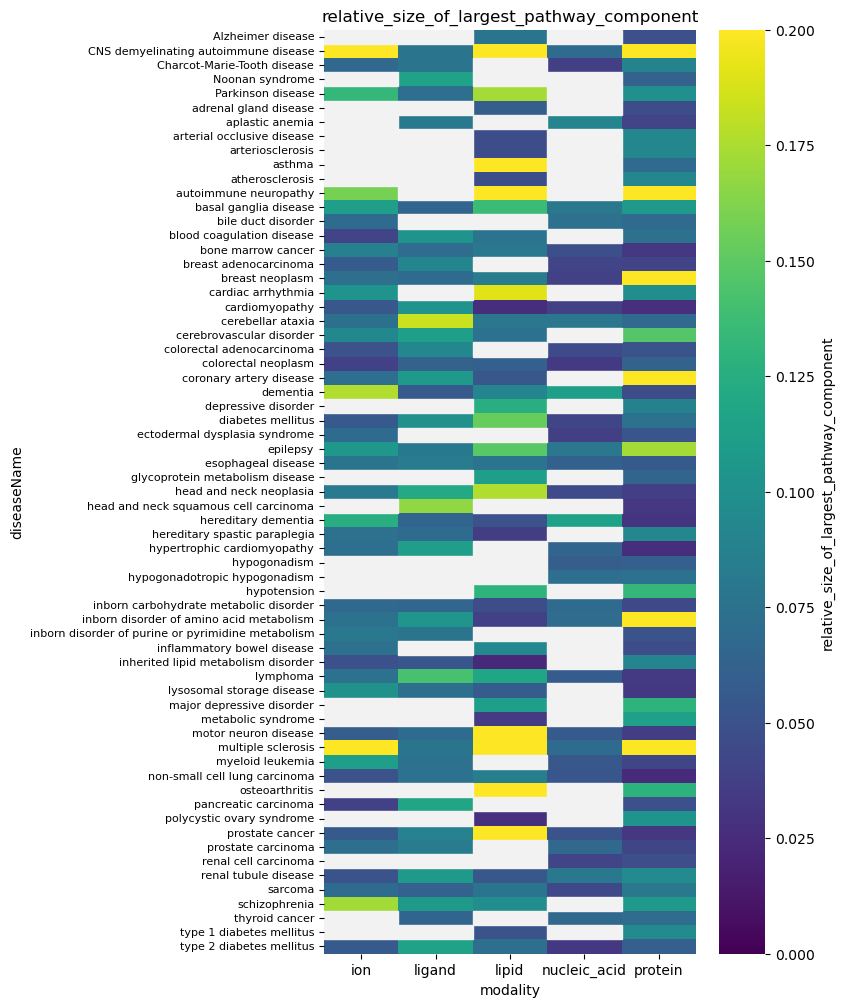

In [22]:
chosen_metric = 'relative_size_of_largest_pathway_component'
pivoted_df = pd.pivot_table(disease_connectivity_df[disease_connectivity_df['number_of_nodes'] > 1], 
                            values=chosen_metric, 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.sort_values(by='diseaseName')
pivoted_df = pivoted_df[~pivoted_df['diseaseName'].isin(['nutritional or metabolic disease', 'thyroid carcinoma'])]

# remove the diseases with less than 25 proteins
min_modality_protein_count = 25
for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
    pivoted_df[modality] = pivoted_df.apply(lambda row: row[modality] if modality_disease_counts.loc[(row['diseaseId'], row['diseaseName'])][modality] >= min_modality_protein_count else -1, axis=1)

pivoted_df['sufficient_data'] = pivoted_df.apply(lambda row: sum([1 for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid'] if row[modality] != -1]) > 1, axis=1)
print(f"Number of diseases with sufficient data in at least two modalities: {sum(pivoted_df['sufficient_data'])} out of {len(pivoted_df)}")
pivoted_df = pivoted_df[pivoted_df['sufficient_data']]
pivoted_df = pivoted_df.drop('sufficient_data', axis=1)

plt.figure(figsize=(6,12))
plotting_df = pivoted_df.set_index('diseaseName').drop('diseaseId', axis=1)
mask = plotting_df==-1
ax = sns.heatmap(plotting_df, cmap='viridis', mask=mask, cbar_kws={"label": chosen_metric}, vmin=0, vmax=0.2)
for i, j in zip(*np.where(mask)):
    plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fc='#F2F2F2', ec='#F2F2F2'))
ax.set_yticklabels(ax.get_yticklabels(), va='center')
plt.yticks(np.arange(len(plotting_df)) + 0.5, plotting_df.index, rotation=0)
plt.yticks(fontsize=8)
plt.title(chosen_metric)
plt.show()

In [14]:
disease_connectivity_df[(disease_connectivity_df['number_of_nodes']>=25) & (disease_connectivity_df['modality'] == 'ligand')].sort_values('size_of_largest_connected_component', ascending=False).head(20)

,modality,diseaseId,size_of_largest_connected_component,number_of_nodes,relative_size_of_largest_pathway_component,relative_size_of_number_of_nodes,num_components,density,clustering,proteins_in_largest_component,all_proteins,components,diseaseName,size_of_top_three,relative_size_of_top_three
173,ligand,OTAR_0000020,477,604,0.789735,0.397892,96,0.009061,0.361694,"[P15692, Q13615, P51451, O75356, O43272, Q9Y4W...","[P48506, Q9UJS0, P30988, P21439, Q53H12, Q1288...","[{4098, 4099, 4106, 12, 4119, 4133, 4147, 4155...",nutritional or metabolic disease,483,0.799669
58,ligand,EFO_0000574,15,106,0.141509,0.358108,66,0.008805,0.114780,"[P49643, P12931, P42338, P51451, P01112, P0863...","[P09769, P28907, P06241, P20273, Q14181, P2544...","[{1316, 5833, 3082, 4106, 5084, 3629, 3598, 36...",lymphoma,26,0.245283
393,ligand,EFO_0003869,10,145,0.068966,0.342790,83,0.008046,0.167816,"[Q15262, P07949, Q5JWF2, P50148, Q9BYW2, P0435...","[P38398, Q14181, P14210, P49959, Q70Z35, Q0660...","[{3521, 2891, 141, 4593, 5747, 4403, 5818, 489...",breast neoplasm,25,0.172414
388,ligand,MONDO_0004736,10,96,0.104167,0.400000,65,0.007675,0.067708,"[Q02252, Q9ULK4, Q4G176, Q96N76, P51649, Q9GZZ...","[Q9UJS0, P49184, P31327, P00480, P54886, P1467...","[{5794, 5287, 4011, 5777, 5715, 5716, 3574, 47...",inborn disorder of amino acid metabolism,21,0.218750
13,ligand,EFO_0000474,8,99,0.080808,0.370787,62,0.008452,0.085859,"[P11166, Q9UHK6, Q9H2X9, P31644, P61328, Q8TDJ...","[Q9NY47, P17600, Q9P0K1, Q9BYZ6, O00116, Q9305...","[{5609, 3466, 5452, 3793, 5462, 188, 3582, 531...",epilepsy,19,0.191919
368,ligand,EFO_0000318,8,78,0.102564,0.375000,52,0.009990,0.111111,"[P04049, P10398, Q6VAB6, P12931, P36871, Q1663...","[P49184, Q9NQL2, O60706, Q7Z4I7, P49748, P3104...","[{3297, 3426, 4675, 5833, 5739, 5740, 4588, 53...",cardiomyopathy,20,0.256410
428,ligand,EFO_0005950,7,58,0.120690,0.360248,42,0.013309,0.079310,"[Q5JWF2, P50148, P04350, P29992, P63000, Q9H4B...","[P38398, P14210, Q70Z35, P42338, P21860, P2180...","[{141, 4593, 4403, 5175, 4285, 3069, 3550}, {5...",head and neck neoplasia,14,0.241379
423,ligand,MONDO_0000437,7,38,0.184211,0.380000,29,0.012802,0.000000,"[Q3T906, P49638, Q9H6L2, Q9Y6Y1, Q10713, O7592...","[P35251, Q9NUW8, P54252, Q9GZZ9, Q92915, P1363...","[{5697, 3874, 2827, 4814, 4886, 4759, 2943}, {...",cerebellar ataxia,11,0.289474
198,ligand,EFO_0004142,6,96,0.062500,0.421053,63,0.008114,0.062500,"[Q15262, P31749, P01111, P19447, P01116, Q13469]","[P38398, P19971, P35221, O75417, P78549, P2186...","[{3521, 2966, 4696, 3034, 4890, 5818}, {5607, ...",colorectal neoplasm,16,0.166667
308,ligand,EFO_0003060,5,66,0.075758,0.528000,54,0.006993,0.116162,"[P07949, Q9BYW2, P04350, Q9H4B7, Q9BUF5]","[P14210, O75417, P42338, P21860, P21802, P2260...","[{2891, 5747, 4403, 3069, 3550}, {3297, 3082, ...",non-small cell lung carcinoma,12,0.181818


If you are interested in studying a specific disease and a specific modality you can change `chosen_disease` and `chosen_modality`

In [25]:
chosen_disease = 'Charcot-Marie-Tooth disease'
chosen_modality = 'ion'

largest_component_disease_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['proteins_in_largest_component'].values[0]
disease_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['all_proteins'].values[0]
print("number of disease proteins in largest component", len(largest_component_disease_proteins))
print("disease proteins in largest component", " ".join(largest_component_disease_proteins))
print("number of disease proteins", len(disease_proteins))
print("disease proteins", " ".join(disease_proteins))

number of disease proteins in largest component 2
disease proteins in largest component Q96JI7 O60333
number of disease proteins 30
disease proteins Q9NW08 Q96T60 O60333 Q15120 P51149 P50570 P49588 Q14573 P12036 P78504 Q96JI7 Q71SY5 Q9C040 O95140 P11161 Q5TAQ9 P38935 Q9Y6X9 Q96M96 Q9UHW9 P60891 Q6UWE0 P19367 P05023 P55072 P56192 Q96HY7 Q99732 P08473 P07196


In [20]:
chosen_disease_components = []
components = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['components'].iloc[0]
for component_idx, component in enumerate(components):
    uniprot_to_node_idx = modality_graphs[chosen_modality]['uniprot_to_node_idx']
    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    for node in component:
        chosen_disease_components.append([component_idx, node, node_idx_to_uniprot[node]])
chosen_disease_components_df = pd.DataFrame(chosen_disease_components, columns=['component_idx', 'node', 'uniprot'])
chosen_disease_components_df['gene'] = chosen_disease_components_df['uniprot'].map(uniprot_to_gene)
chosen_disease_components_df['protein_name'] = chosen_disease_components_df['uniprot'].map(uniprot_to_protein_name)

chosen_disease_components_df.head(50)

,component_idx,node,uniprot,gene,protein_name
0,0,5863,Q9NY46,SCN3A KIAA1356 NAC3,Sodium channel protein type 3 subunit alpha (S...
1,0,6538,Q01118,SCN7A SCN6A,Sodium channel protein type 7 subunit alpha (A...
2,0,5226,Q9UQD0,SCN8A MED,Sodium channel protein type 8 subunit alpha (S...
3,0,4398,Q99250,SCN2A HBA NAC2 SCN2A1 SCN2A2,Sodium channel protein type 2 subunit alpha (H...
4,0,5231,P35498,SCN1A NAC1 SCN1,Sodium channel protein type 1 subunit alpha (S...
5,0,6543,P35499,SCN4A,Sodium channel protein type 4 subunit alpha (S...
6,0,6739,Q15858,SCN9A NENA,Sodium channel protein type 9 subunit alpha (N...
7,0,6036,Q9Y5Y9,SCN10A,Sodium channel protein type 10 subunit alpha (...
8,0,4212,Q14524,SCN5A,Sodium channel protein type 5 subunit alpha (S...
9,1,5784,P29275,ADORA2B,Adenosine receptor A2b


In [60]:
chosen_metric = 'size_of_largest_connected_component'
pivoted_df = pd.pivot_table(disease_connectivity_df[disease_connectivity_df['number_of_nodes'] > 1], 
                            values=chosen_metric, 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.sort_values(by='diseaseName')
pivoted_df.sort_values('ligand', ascending=False).head(20)

modality,diseaseId,diseaseName,ion,ligand,lipid,nucleic_acid,protein
102,OTAR_0000020,nutritional or metabolic disease,275.0,477.0,176.0,54.0,482.0
12,EFO_0000574,lymphoma,8.0,15.0,9.0,7.0,7.0
30,EFO_0003869,breast neoplasm,10.0,10.0,11.0,7.0,71.0
68,MONDO_0004736,inborn disorder of amino acid metabolism,7.0,10.0,3.0,3.0,45.0
6,EFO_0000318,cardiomyopathy,4.0,8.0,2.0,2.0,4.0
9,EFO_0000474,epilepsy,11.0,8.0,20.0,5.0,39.0
39,EFO_0005950,head and neck neoplasia,4.0,7.0,9.0,3.0,4.0
53,MONDO_0000437,cerebellar ataxia,3.0,7.0,3.0,3.0,5.0
33,EFO_0004142,colorectal neoplasm,3.0,6.0,3.0,4.0,11.0
25,EFO_0003060,non-small cell lung carcinoma,2.0,5.0,3.0,3.0,2.0


## Disease module detection algorithms

We run three disease module detection algorithms on the 5 networks (random walk, neighborhood, and DIAMOnD). For a given disease we run a 5 fold cross validation where we select one fold (20%) of disease-associated proteins to be test proteins and the remaining 80% to be seed proteins. We then run the disease module detection algorithm and evaluate proteins detected in the top 500 nominated proteins. This is repeated 64 times for each disease.


Random Walk performs the best.

In [81]:
from glob import glob
num_completed = len(glob("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_split_*_fix_irreps.pkl"))
num_completed

100

In [178]:
import pandas as pd
import pickle 
import os

results_df = pd.DataFrame()
for i in range(100):
    fname = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_split_{i}_fix_irreps.pkl"
    if not os.path.exists(fname):
        print(f"{i} does not exist")
        continue
    with open(fname, "rb") as f:
        results = pickle.load(f)
        results_df = pd.concat([results_df, results])

In [88]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_fix_irreps.pkl", "wb") as f:
    pickle.dump(results_df, f)

In [136]:
num_found_per_disease = []
for disease in tqdm(results_df['diseaseName'].unique(), total=len(results_df['diseaseName'].unique())):
    for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
        found_proteins = sum(results_df[(results_df['diseaseName'] == disease) & (results_df['modality'] == modality)]['found_rw'].dropna().values.tolist(), [])
        found_proteins = set(found_proteins)
        gt_proteins = disease_associations[disease_associations['diseaseName'] == disease]['uniprot_targetId'].unique()
        found_proteins = found_proteins.intersection(set(gt_proteins))
        num_found_per_disease.append((disease, modality, len(found_proteins), found_proteins))
num_found_per_disease_df = pd.DataFrame(num_found_per_disease, columns=['diseaseName', 'modality', 'num_found_proteins', 'found_proteins'])
num_found_per_disease_df

100%|██████████| 95/95 [00:59<00:00,  1.58it/s]


,diseaseName,modality,num_found_proteins,found_proteins
0,nutritional or metabolic disease,protein,74,"{P23560, P22309, P07101, P17568, Q53GQ0, Q9283..."
1,nutritional or metabolic disease,ligand,122,"{P18074, P08397, Q86XA0, P00558, O00519, Q8TB3..."
2,nutritional or metabolic disease,nucleic_acid,47,"{P42345, P17568, P51530, Q96IV0, Q9NXH9, P0389..."
3,nutritional or metabolic disease,ion,125,"{P78363, O60658, O95394, P11498, Q8TEQ8, P0036..."
4,nutritional or metabolic disease,lipid,132,"{Q9H3H5, Q9Y5Y9, Q9Y6R1, P03891, O15118, O6026..."
...,...,...,...,...
470,peroxisomal disease,protein,0,{}
471,peroxisomal disease,ligand,0,{}
472,peroxisomal disease,nucleic_acid,0,{}
473,peroxisomal disease,ion,0,{}


In [171]:
num_found_per_disease_per_modality_df = num_found_per_disease_df.pivot_table(index='diseaseName', columns='modality', values='num_found_proteins', fill_value=0).reset_index()
num_found_per_disease_per_modality_df.head(50)

modality,diseaseName,ion,ligand,lipid,nucleic_acid,protein
0,Alzheimer disease,0.0,0.0,7.0,0.0,1.0
1,CNS demyelinating autoimmune disease,27.0,2.0,40.0,11.0,17.0
2,Charcot-Marie-Tooth disease,2.0,1.0,0.0,2.0,2.0
3,Joubert syndrome,0.0,0.0,0.0,0.0,1.0
4,Leigh syndrome,0.0,0.0,0.0,0.0,6.0
5,Noonan syndrome,0.0,4.0,0.0,0.0,1.0
6,Parkinson disease,4.0,3.0,14.0,0.0,2.0
7,Spinocerebellar ataxia with oculomotor anomaly,0.0,0.0,0.0,0.0,3.0
8,T-cell and NK-cell neoplasm,0.0,0.0,0.0,0.0,0.0
9,adrenal gland disease,0.0,0.0,7.0,0.0,1.0


In [83]:
mean_results_df = results_df.groupby(['diseaseId', 'diseaseName', 'modality']).agg({
    'num_found_diamond': 'sum',
    'num_found_rw': 'sum',
    'num_found_neighborhood': 'sum',
    'recall_diamond': 'mean',
    'recall_rw': 'mean',
    'recall_neighborhood': 'mean',
}).reset_index()

In [84]:
print("Discovered by Diamond: ", mean_results_df['recall_diamond'].mean(), mean_results_df['recall_diamond'].std())
print("Discovered by Random Walk: ", mean_results_df['recall_rw'].mean(), mean_results_df['recall_rw'].std())
print("Discovered by Neighborhood: ", mean_results_df['recall_neighborhood'].mean(), mean_results_df['recall_neighborhood'].std())

Discovered by Diamond:  0.09912393615590748 0.07958650406677978
Discovered by Random Walk:  0.11434616144413912 0.10106958818876252
Discovered by Neighborhood:  0.09672589623484294 0.08948600337250937


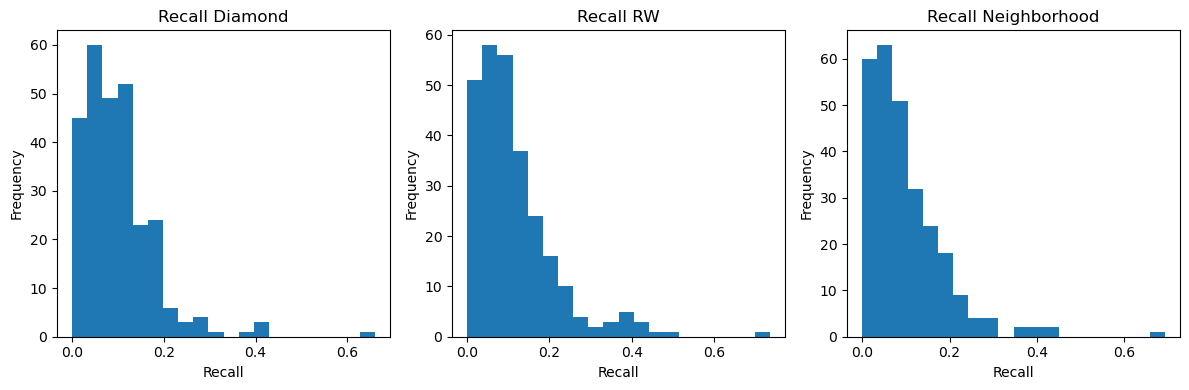

In [85]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
mean_results_df['recall_diamond'].hist(bins=20, ax=ax1)
mean_results_df['recall_rw'].hist(bins=20, ax=ax2)
mean_results_df['recall_neighborhood'].hist(bins=20, ax=ax3)
ax1.set_title('Recall Diamond')
ax2.set_title('Recall RW')
ax3.set_title('Recall Neighborhood')
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('Recall')
    ax.set_ylabel('Frequency')
    ax.grid(False)
plt.tight_layout()
plt.show()

Number of ground truth proteins:  228


100%|██████████| 2500/2500 [00:00<00:00, 7864.99it/s]
/tmp/ipykernel_26339/3436545853.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  found_matrix[i,j] = found['count']


Number of proteins found:  62


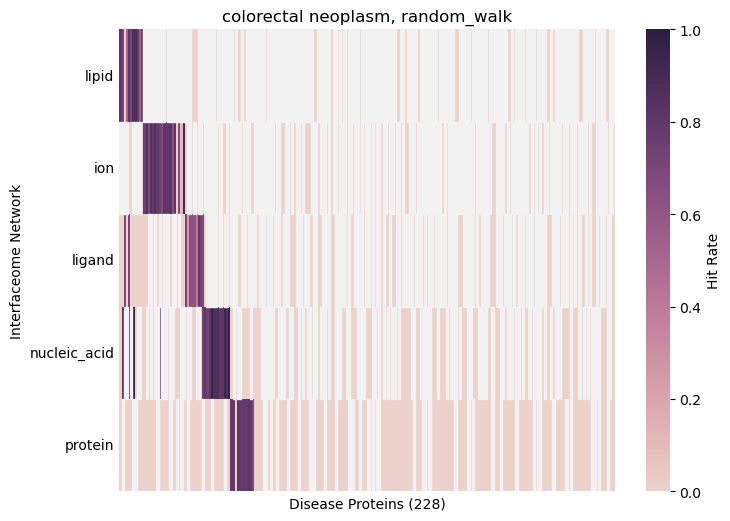

In [192]:
chosen_disease_name = 'colorectal neoplasm'

chosen_method = 'random_walk'
chosen_disease = disease_name_to_id[chosen_disease_name]

modalities = ['protein', 'lipid', 'nucleic_acid', 'ligand', 'ion']
gt_proteins = set(disease_associations[disease_associations['diseaseId'] == chosen_disease]['uniprot_targetId'].to_list())
print("Number of ground truth proteins: ", len(gt_proteins))

found_list = []
for _, row in tqdm(results_df[results_df['diseaseId'] == chosen_disease].iterrows(), total=len(results_df[results_df['diseaseId'] == chosen_disease])):
    if row['found_diamond'] is pd.NA:
        row['found_diamond'] = []
    if row['found_rw'] is pd.NA:
        row['found_rw'] = []
    if row['found_neighborhood'] is pd.NA:
        row['found_neighborhood'] = []
    for found_prot in set(row['found_diamond']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "diamond"})
    for found_prot in set(row['found_rw']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "random_walk"})
    for found_prot in set(row['found_neighborhood']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "neighborhood"})
found_df = pd.DataFrame(found_list)
found_df = found_df.groupby(['modality', 'model', 'found_prot']).size().reset_index(name='count')

print("Number of proteins found: ", len(found_df[found_df['model'] == chosen_method]['found_prot'].unique()))


found_matrix = np.zeros((len(modalities), len(gt_proteins)))

num_trials = results_df[results_df['diseaseId'] == chosen_disease][['modality', 'fold']].value_counts().mean()
for i, modality in enumerate(modalities):
    for j, protein in enumerate(gt_proteins):
        found = found_df[(found_df['modality'] == modality) & (found_df['model'] == chosen_method) & (found_df['found_prot'] == protein)]
        if len(found) > 0:
            found_matrix[i,j] = found['count']
        elif not protein in modality_graphs[modality]['uniprot_to_node_idx']:
            found_matrix[i,j] = -1
        else:
            protein_idx = modality_graphs[modality]['uniprot_to_node_idx'][protein]
            if protein_idx in modality_graphs[modality]['largest_component']:
                found_matrix[i,j] = 0
            else:
                found_matrix[i,j] = -1
found_matrix[found_matrix > 0] = found_matrix[found_matrix > 0] / num_trials
assert found_matrix.max() <= 1

protein_order = []
modality_order = (found_matrix >= 0).sum(axis=1).argsort()
for modality in modality_order: # order modalities by number of found proteins
    for prot in np.where(found_matrix[modality] > 0)[0]:
        if prot not in protein_order:
            protein_order.append(prot)
for i in range(found_matrix.shape[1]):
    if i not in protein_order:
        protein_order.append(i)
found_matrix = found_matrix[:,protein_order]
found_matrix = found_matrix[modality_order]

plt.figure(figsize=(8, 6))
mask = found_matrix==-1
ax = sns.heatmap(found_matrix, cmap=sns.cubehelix_palette(as_cmap=True), mask=mask, cbar_kws={"label": "Hit Rate"}, vmin=0, vmax=1)
for i, j in zip(*np.where(mask)):
    plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fc='#F2F2F2', ec='#F2F2F2'))

plt.yticks(np.arange(len(modalities))+0.5, np.array(modalities)[modality_order], rotation=0)
if len(gt_proteins) < 50:
    plt.xticks(np.arange(len(gt_proteins))+0.5, np.array(list(gt_proteins))[protein_order], rotation=90)
else:
    ax.set_xticklabels([])
    ax.set_xticks([])
ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)
plt.title(f"{disease_id_to_name[chosen_disease]}, {chosen_method}")
plt.ylabel("Interfaceome Network")
plt.xlabel(f"Disease Proteins ({len(gt_proteins)})")
plt.show()
        

In [195]:
found_proteins_by_network = found_df[found_df.model == chosen_method].pivot_table(index='found_prot', columns='modality', values='count').fillna(0).reset_index()
found_proteins_by_network['gene'] = found_proteins_by_network['found_prot'].map(uniprot_to_gene)
found_proteins_by_network['protein_name'] = found_proteins_by_network['found_prot'].map(uniprot_to_protein_name)

found_proteins_by_network.sort_values('nucleic_acid', ascending=False).head(20)

modality,found_prot,ion,ligand,lipid,nucleic_acid,protein,gene,protein_name
5,P00533,0.0,0.0,87.0,96.0,0.0,EGFR ERBB ERBB1 HER1,Epidermal growth factor receptor (EC 2.7.10.1)...
13,P11362,0.0,71.0,81.0,96.0,0.0,FGFR1 BFGFR CEK FGFBR FLG FLT2 HBGFR,Fibroblast growth factor receptor 1 (FGFR-1) (...
27,P33076,0.0,0.0,0.0,96.0,0.0,CIITA MHC2TA,MHC class II transactivator (CIITA) (EC 2.3.1....
51,Q6N021,0.0,0.0,0.0,95.0,0.0,TET2 KIAA1546 Nbla00191,Methylcytosine dioxygenase TET2 (EC 1.14.11.80)
57,Q8NFU7,0.0,0.0,0.0,93.0,0.0,TET1 CXXC6 KIAA1676 LCX,Methylcytosine dioxygenase TET1 (EC 1.14.11.80...
20,P19447,0.0,0.0,0.0,87.0,0.0,ERCC3 XPB XPBC,General transcription and DNA repair factor II...
52,Q6P1J9,0.0,0.0,0.0,87.0,0.0,CDC73 C1orf28 HRPT2,Parafibromin (Cell division cycle protein 73 h...
37,P48431,0.0,0.0,0.0,86.0,0.0,SOX2,Transcription factor SOX-2
48,Q16720,0.0,0.0,0.0,86.0,0.0,ATP2B3,Plasma membrane calcium-transporting ATPase 3 ...
22,P22607,0.0,0.0,70.0,83.0,0.0,FGFR3 JTK4,Fibroblast growth factor receptor 3 (FGFR-3) (...
